# Outfit Recommendation System



## Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Re-PolyVore.zip'
extract_path = '/content/Re-PolyVore'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print("Dataset unzipped!")
else:
    print("Dataset already extracted.")


Dataset unzipped!


In [ ]:
import tensorflow as tf
print("Available GPU:", tf.config.list_physical_devices('GPU'))


Available GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
dataset_path = "/content/Re-PolyVore/Re-PolyVore"


In [ ]:
import os
import cv2
import numpy as np
import itertools
import random
import logging
from sklearn.cluster import KMeans
from tf_keras.models import Model
from tf_keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Concatenate, BatchNormalization, Dropout
from tf_keras.optimizers import Adam
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint
from tf_keras.utils import Sequence
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s [%(levelname)s] %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

## Image Loader & Metadata Reader

In [ ]:
import os

dataset_path = "/content/Re-PolyVore/Re-PolyVore"
print("Folders:", os.listdir(dataset_path))


Folders: ['pants', 'shoes', 'hats', 'neckwear', 'eyewear', 'hairwear', 'skirt', 'bag', 'watches', 'rings', 'brooch', 'dress', 'jumpsuit', 'earrings', 'gloves', 'top', 'outwear', 'legwear', 'bracelet', 'necklace']


In [ ]:
print("Sample from 'top':", os.listdir(os.path.join(dataset_path, "top"))[:5])


Sample from 'top': ['71329955_1.jpg', '196867180_1.jpg', '215662503_1.jpg', '182236886_2.jpg', '214399067_1.jpg']


In [ ]:
# Load and preprocess image
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image not found: {image_path}")
    image = cv2.resize(image, target_size)
    return image.astype('float32') / 255.0

In [ ]:
def load_polyvore_metadata(root_dir, target_size=(128, 128)):
    import os
    import numpy as np
    import cv2
    import random

    allowed_categories = {
        "top", "skirt", "pants", "outwear", "dress", "jumpsuit",
        "shoes", "bag", "earrings", "necklace", "rings", "bracelet",
        "watches", "hats", "eyewear", "gloves", "legwear", "neckwear",
        "hairwear", "brooch"
    }

    categories = []
    folder_mapping = {}
    for folder in os.listdir(root_dir):
        folder_lower = folder.lower()
        if folder_lower in allowed_categories:
            folder_mapping[folder_lower] = folder
            categories.append(folder_lower)

    categories.sort()
    category_to_index = {cat: i for i, cat in enumerate(categories)}

    file_paths, metadata, likes, items = [], [], [], []
    item_id = 0

    for category in categories:
        folder_path = os.path.join(root_dir, folder_mapping[category])
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(folder_path, fname)
            if cv2.imread(img_path) is None:
                continue

            file_paths.append(img_path)

            one_hot = np.zeros(len(categories), dtype=np.float32)
            one_hot[category_to_index[category]] = 1.0
            metadata.append(one_hot)

            likes.append(np.log1p(random.randint(1, 300)))

            items.append({
                'id': item_id,
                'image_path': img_path,
                'category': category,
                'embedding': np.random.rand(128)
            })

            item_id += 1

    return file_paths, metadata, likes, items


In [ ]:
file_paths, metadata, likes, items = load_polyvore_metadata(dataset_path)
print(f"Loaded {len(file_paths)} image paths from dataset.")



Loaded 126928 image paths from dataset.


In [ ]:
print(f"Loaded {len(file_paths)} image paths")
print(f"Metadata size: {len(metadata)}")
print(f"Likes size: {len(likes)}")


Loaded 126928 image paths
Metadata size: 126928
Likes size: 126928


## Data Generators

In [ ]:
class AutoencoderDataGenerator(Sequence):
    def __init__(self, file_paths, batch_size=32, target_size=(128, 128), shuffle=True):
        self.file_paths = file_paths
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = [self.file_paths[i] for i in batch_indices]
        images = [load_and_preprocess_image(p, self.target_size) for p in batch_files]
        X = np.array(images, dtype=np.float32)
        return X, X

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## Model Architectures

In [ ]:
def build_deep_autoencoder(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(input_shape[2], (3, 3), activation='sigmoid', padding='same')(UpSampling2D((2, 2))(x))
    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
    return autoencoder, encoder

## Model Training

In [ ]:
from tf_keras.callbacks import EarlyStopping, ModelCheckpoint
import os

dataset_path = '/content/Re-PolyVore/Re-PolyVore'

file_paths, metadata, likes, virtual_closet = load_polyvore_metadata(dataset_path)
input_shape = (128, 128, 3)

autoencoder, encoder = build_deep_autoencoder(input_shape)

ae_generator = AutoencoderDataGenerator(
    file_paths=file_paths,
    batch_size=32,
    target_size=(128, 128),
    shuffle=True
)

os.makedirs("models", exist_ok=True)

early_stop_ae = EarlyStopping(
    monitor='loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint_ae = ModelCheckpoint(
    filepath='models/autoencoder_best.h5',
    monitor='loss',
    save_best_only=True,
    verbose=1
)

autoencoder.fit(
    ae_generator,
    epochs=3,
    callbacks=[early_stop_ae, checkpoint_ae],
    verbose=1
)


Epoch 1/3
3967/3967 [==============================] - ETA: 0s - loss: 0.0093
Epoch 1: loss improved from inf to 0.00931, saving model to models/autoencoder_best.h5
3967/3967 [==============================] - 424s 105ms/step - loss: 0.0093
Epoch 2/3


/usr/local/lib/python3.11/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3967/3967 [==============================] - ETA: 0s - loss: 0.0055
Epoch 2: loss improved from 0.00931 to 0.00546, saving model to models/autoencoder_best.h5
3967/3967 [==============================] - 412s 104ms/step - loss: 0.0055
Epoch 3/3
3967/3967 [==============================] - ETA: 0s - loss: 0.0048
Epoch 3: loss improved from 0.00546 to 0.00481, saving model to models/autoencoder_best.h5
3967/3967 [==============================] - 411s 104ms/step - loss: 0.0048
Restoring model weights from the end of the best epoch: 3.


## Outfit Recommendation & Clustering

In [ ]:
def generate_outfit_combinations(wardrobe):
    categories = set(item['category'] for item in wardrobe)
    category_items = {cat: [item for item in wardrobe if item['category'] == cat] for cat in categories}
    outfit_combinations = list(itertools.product(*category_items.values()))
    return outfit_combinations

def cluster_outfits(embeddings, num_clusters=5):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    return kmeans.fit_predict(embeddings)

In [ ]:

from tf_keras.utils import Sequence
import numpy as np

class MultiModalDataGenerator(Sequence):
    def __init__(self, file_paths, metadata, likes, encoder,
                 batch_size=64, target_size=(128, 128), shuffle=True):
        self.file_paths = file_paths
        self.metadata = metadata
        self.likes = likes
        self.encoder = encoder
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.file_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = [self.file_paths[i] for i in batch_indices]
        batch_meta = [self.metadata[i] for i in batch_indices]
        batch_likes = [self.likes[i] for i in batch_indices]

        # Load and preprocess images
        images = [load_and_preprocess_image(p, self.target_size) for p in batch_files]
        images = np.array(images, dtype=np.float32)

        # Get embeddings from encoder
        embeddings = self.encoder.predict(images, verbose=0)

        meta = np.array(batch_meta, dtype=np.float32)
        likes = np.array(batch_likes).reshape(-1, 1)

        return [embeddings, meta], likes

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [ ]:

from tf_keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from tf_keras.models import Model
from tf_keras.optimizers import Adam

metadata_input_dim = len(metadata[0])
image_embedding_shape = encoder.output_shape[1:]

def build_multimodal_model(image_shape, metadata_dim):
    image_input = Input(shape=image_shape, name="image_input")
    x = Flatten()(image_input)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    metadata_input = Input(shape=(metadata_dim,), name="metadata_input")
    y = Dense(64, activation='relu')(metadata_input)
    y = Dropout(0.3)(y)

    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    output = Dense(1, activation='linear')(z)

    model = Model(inputs=[image_input, metadata_input], outputs=output)
    model.compile(optimizer=Adam(1e-4), loss='mse', metrics=['mae'])
    return model

multimodal_model = build_multimodal_model(image_embedding_shape, metadata_input_dim)


In [ ]:

from tf_keras.callbacks import EarlyStopping

mm_generator = MultiModalDataGenerator(
    file_paths=file_paths,
    metadata=metadata,
    likes=likes,
    encoder=encoder,
    batch_size=64,
    target_size=(128, 128)
)

early_stop = EarlyStopping(patience=3, monitor='loss', restore_best_weights=True)


print("Training multi-modal model using generator...")
multimodal_model.fit(
    mm_generator,
    epochs=2,
    callbacks=[early_stop],
    verbose=1
)


Training multi-modal model using generator...
Epoch 1/2
1984/1984 [==============================] - 500s 251ms/step - loss: 1.6684 - mae: 0.9392
Epoch 2/2
1984/1984 [==============================] - 507s 256ms/step - loss: 1.0180 - mae: 0.7629


In [ ]:
multimodal_model.save("/content/multimodal_model.h5")
encoder.save("/content/encoder_model.h5")


In [ ]:

sample_img_path = file_paths[0]
sample_image = load_and_preprocess_image(sample_img_path)
sample_embedding = encoder.predict(np.expand_dims(sample_image, axis=0))

sample_metadata = np.expand_dims(metadata[0], axis=0)

predicted_likes = multimodal_model.predict([sample_embedding, sample_metadata])
print("Predicted Likes (log scale):", predicted_likes[0][0])


1/1 [==============================] - 0s 74ms/step
Predicted Likes (log scale): 3.0140147


In [ ]:
actual_likes = np.expm1(predicted_likes[0][0])
print("Estimated Likes:", round(actual_likes))


Estimated Likes: 19


In [ ]:
import random
import numpy as np

def assign_compatibility_score(outfit):
    """
    Uses trained encoder and multimodal model to assign a compatibility score for an outfit.
    """
    images = [load_and_preprocess_image(item['image_path']) for item in outfit]
    images = np.array(images, dtype=np.float32)
    embeddings = encoder.predict(images, verbose=0)

    mean_embedding = np.mean(embeddings, axis=0).reshape(1, *embeddings.shape[1:])

    meta_vectors = [item['metadata'] for item in outfit if 'metadata' in item]
    mean_meta = np.mean(np.array(meta_vectors), axis=0).reshape(1, -1)

    score = multimodal_model.predict([mean_embedding, mean_meta], verbose=0)
    return float(score[0][0])


In [ ]:

def generate_random_outfit_combinations(wardrobe, num_samples=10):
    categories = set(item['category'] for item in wardrobe)
    category_items = {cat: [item for item in wardrobe if item['category'] == cat] for cat in categories}

    for item in wardrobe:
        if 'metadata' not in item:
            index = file_paths.index(item['image_path'])
            item['metadata'] = metadata[index]

    outfits = []
    for _ in range(num_samples):
        if not all(category_items.values()):
            continue
        outfit = [random.choice(category_items[cat]) for cat in category_items]
        outfits.append(outfit)
    return outfits


In [ ]:

print("Generating outfit recommendations...")
sampled_outfits = generate_random_outfit_combinations(virtual_closet, num_samples=10)

recommendations = []
for outfit in sampled_outfits:
    try:
        score = assign_compatibility_score(outfit)
        desc = ", ".join([f"{item['category']}" for item in outfit])
        recommendations.append((desc, round(score, 2)))
    except Exception as e:
        print("Error scoring outfit:", e)


print("\nTop Outfit Recommendations:\n")
for i, (desc, score) in enumerate(recommendations, 1):
    print(f"{i}. Outfit: {desc} | Score: {score}")


Generating outfit recommendations...

Top Outfit Recommendations:

1. Outfit: top, bag, legwear, brooch, watches, hairwear, pants, bracelet, hats, skirt, gloves, eyewear, neckwear, jumpsuit, earrings, dress, rings, shoes, outwear, necklace | Score: 2.97
2. Outfit: top, bag, legwear, brooch, watches, hairwear, pants, bracelet, hats, skirt, gloves, eyewear, neckwear, jumpsuit, earrings, dress, rings, shoes, outwear, necklace | Score: 3.03
3. Outfit: top, bag, legwear, brooch, watches, hairwear, pants, bracelet, hats, skirt, gloves, eyewear, neckwear, jumpsuit, earrings, dress, rings, shoes, outwear, necklace | Score: 3.08
4. Outfit: top, bag, legwear, brooch, watches, hairwear, pants, bracelet, hats, skirt, gloves, eyewear, neckwear, jumpsuit, earrings, dress, rings, shoes, outwear, necklace | Score: 3.03
5. Outfit: top, bag, legwear, brooch, watches, hairwear, pants, bracelet, hats, skirt, gloves, eyewear, neckwear, jumpsuit, earrings, dress, rings, shoes, outwear, necklace | Score: 2.9

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_outfit_images(outfit, score):
    fig, axs = plt.subplots(1, len(outfit), figsize=(15, 3))
    fig.suptitle(f"Outfit Score: {round(score, 2)}", fontsize=14)

    for i, item in enumerate(outfit):
        img = cv2.imread(item['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(item['category'])

    plt.show()


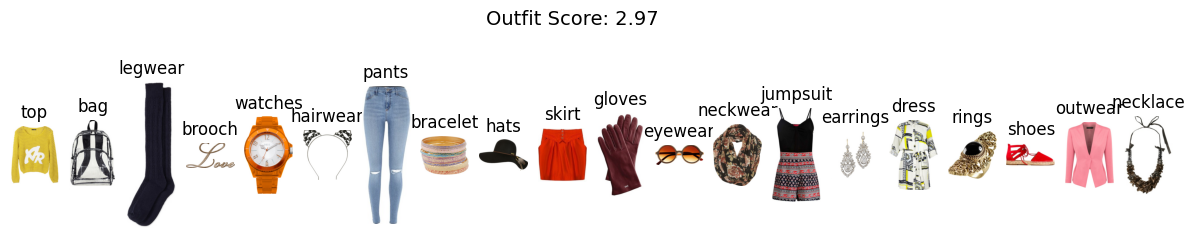

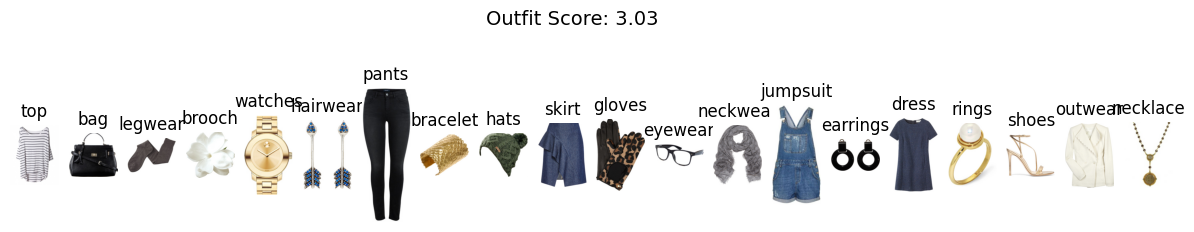

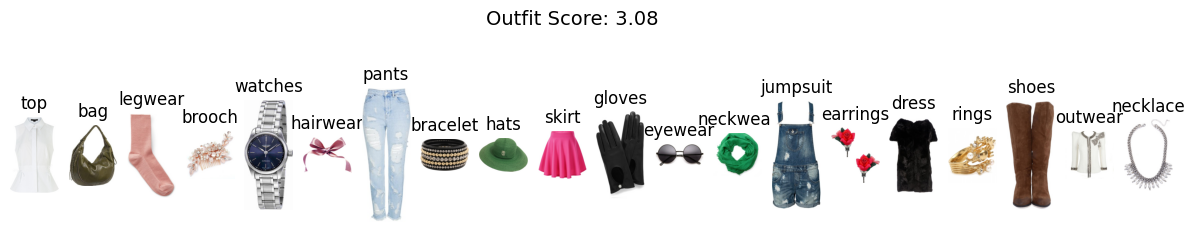

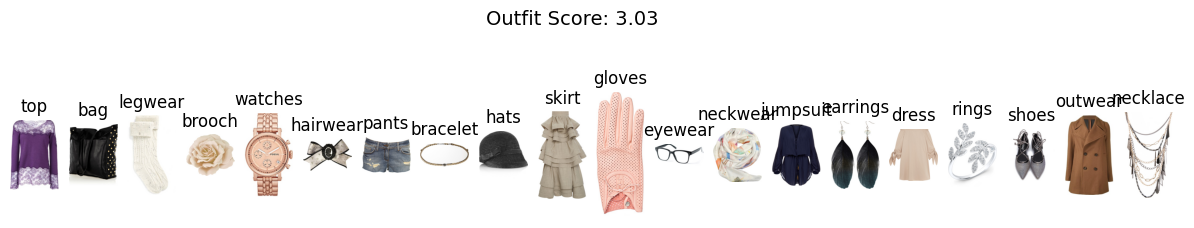

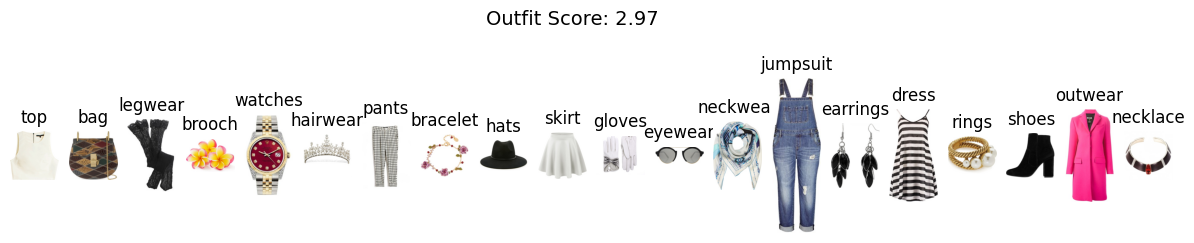

In [ ]:
for outfit in sampled_outfits[:5]:
    score = assign_compatibility_score(outfit)
    display_outfit_images(outfit, score)


In [ ]:
from google.colab import files
files.download("/content/multimodal_model.h5")
files.download("/content/encoder_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>